c:\Users\Dachuuu\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Dachuuu\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


Forecast for next 6 months:
  productionmonth  forecast_volume
0      2026-02-01     4.961193e+08
1      2026-03-01     5.319085e+08
2      2026-04-01     5.133827e+08
3      2026-05-01     5.107470e+08
4      2026-06-01     5.047042e+08
5      2026-07-01     5.333488e+08


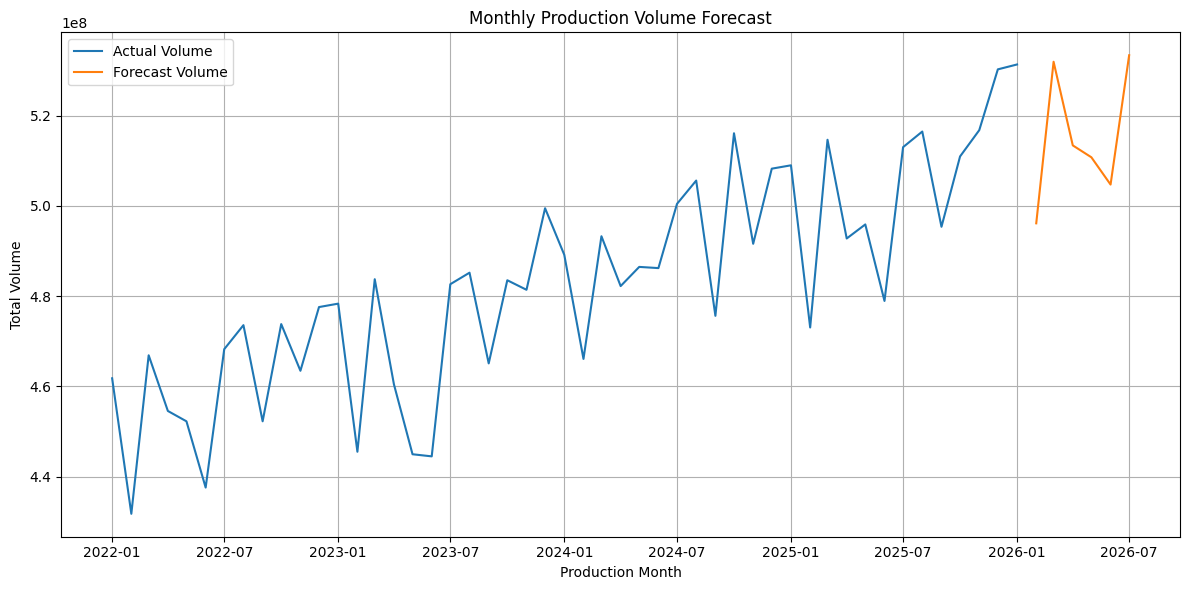

forecast_output.csv has been saved.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# 1. Load the file
df = pd.read_csv("monthly_volume_forecast_prep.csv")

# 2. Clean the columns
df["productionmonth"] = pd.to_datetime(df["productionmonth"])
df = df.sort_values("productionmonth")

# 3. Rename columns to make life easier
df = df.rename(columns={"productionmonth": "ds", "Total Volume": "y"})

# 4. Set date as index
df = df.set_index("ds")

# 5. Build a simple forecasting model
# monthly data + trend + seasonality
model = ExponentialSmoothing(
    df["y"],
    trend="add",
    seasonal="add",
    seasonal_periods=12
)

fit = model.fit()

# 6. Forecast next 6 months
forecast_steps = 6
forecast_values = fit.forecast(forecast_steps)

# 7. Make forecast dates
last_date = df.index[-1]
forecast_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    periods=forecast_steps,
    freq="MS"
)

forecast_df = pd.DataFrame({
    "productionmonth": forecast_dates,
    "forecast_volume": forecast_values.values
})

# 8. Print forecast table
print("Forecast for next 6 months:")
print(forecast_df)

# 9. Plot actual + forecast
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["y"], label="Actual Volume")
plt.plot(forecast_df["productionmonth"], forecast_df["forecast_volume"], label="Forecast Volume")
plt.title("Monthly Production Volume Forecast")
plt.xlabel("Production Month")
plt.ylabel("Total Volume")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 10. Save forecast output
forecast_df.to_csv("forecast_output.csv", index=False)
print("forecast_output.csv has been saved.")